# Problem Statement

Assessing credit risk is crucial for lenders to minimize defaults and make informed loan decisions. Traditional credit scoring models often rely on static data and lack adaptability to changing borrower behavior. Many machine learning models, while accurate, function as black boxes, limiting interpretability.

This project explores Bayesian methods for credit risk assessment, leveraging their ability to incorporate prior knowledge and dynamically update risk estimates. Using a structured loan dataset from Kaggle, we will develop probabilistic models, including Bayesian Logistic Regression and Bayesian Augmented Decision Trees. We will compare these against traditional classifiers like Logistic Regression and Naïve Bayes to evaluate their accuracy, interpretability, and adaptability for financial decision-making.

# EDA & Data Processing

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
print("Dataset Shape:", df.shape)
print("Dataset Info:")
df.info()

Dataset Shape: (32581, 12)
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage

In [ ]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 165


In [ ]:
print("Summary:")
print(df.describe())

Summary:
         person_age  person_income  person_emp_length     loan_amnt  \
count  32581.000000   3.258100e+04       31686.000000  32581.000000   
mean      27.734600   6.607485e+04           4.789686   9589.371106   
std        6.348078   6.198312e+04           4.142630   6322.086646   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.850000e+04           2.000000   5000.000000   
50%       26.000000   5.500000e+04           4.000000   8000.000000   
75%       30.000000   7.920000e+04           7.000000  12200.000000   
max      144.000000   6.000000e+06         123.000000  35000.000000   

       loan_int_rate   loan_status  loan_percent_income  \
count   29465.000000  32581.000000         32581.000000   
mean       11.011695      0.218164             0.170203   
std         3.240459      0.413006             0.106782   
min         5.420000      0.000000             0.000000   
25%         7.900000      0.000000             0.090000 

**Missing values in person_emp_length**: The missing values in person_emp_length were removed since they constitute a small portion of the dataset and do not significantly impact the analysis.


**Missing values in loan_int_rate**: The missing values in loan_int_rate were imputed using the median loan interest rate for the corresponding loan_grade

In [ ]:
df = df.dropna(subset=['person_emp_length'])
print(df["person_emp_length"].isnull().sum())

0


In [ ]:
df_encoded = df.copy()
categorical_features = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
le = LabelEncoder()
for col in categorical_features:
    df_encoded[col] = le.fit_transform(df_encoded[col])

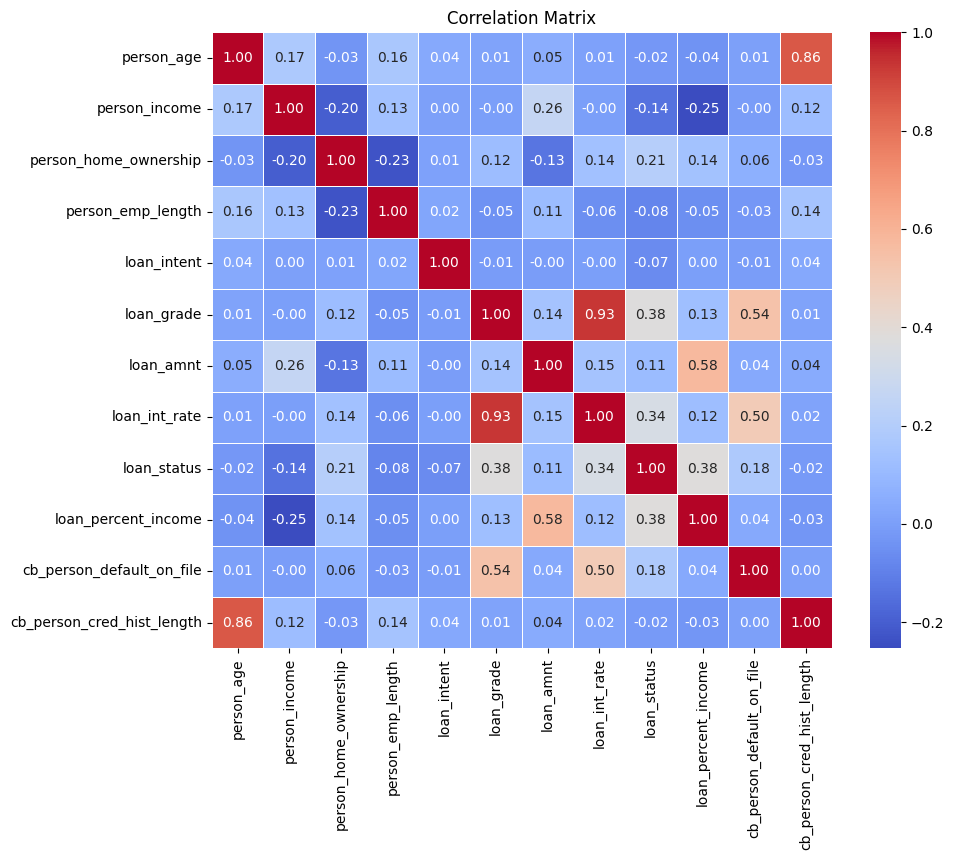

In [ ]:
corr_matrix = df_encoded.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

<ipython-input-45-46d2193deb76>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="loan_grade", y="loan_int_rate", data=df, palette="coolwarm", order=sorted_grades)


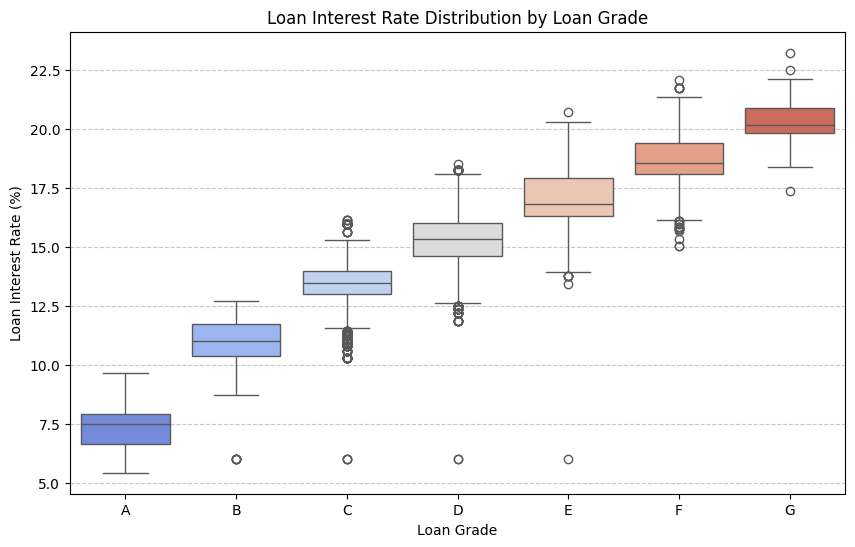

In [ ]:
loan_rate_summary = df.groupby("loan_grade")["loan_int_rate"].agg(["mean", "median", "std", "count"]).reset_index()

sorted_grades = sorted(df["loan_grade"].unique())

plt.figure(figsize=(10, 6))
sns.boxplot(x="loan_grade", y="loan_int_rate", data=df, palette="coolwarm", order=sorted_grades)
plt.xlabel("Loan Grade")
plt.ylabel("Loan Interest Rate (%)")
plt.title("Loan Interest Rate Distribution by Loan Grade")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [ ]:
# fill missing values in loan_int_rate
loan_grade_medians = df.groupby("loan_grade")["loan_int_rate"].median()

df["loan_int_rate"] = df.apply(
    lambda row: loan_grade_medians[row["loan_grade"]] if pd.isnull(row["loan_int_rate"]) else row["loan_int_rate"],
    axis=1
)

print(df["loan_int_rate"].isnull().sum())

0


In [ ]:
print("Missing Values:", df.isnull().sum())

Missing Values: person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


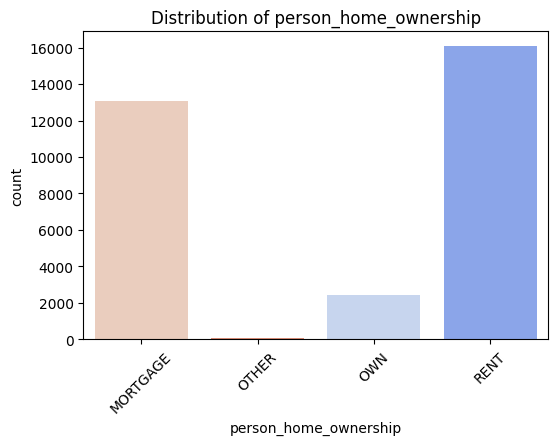

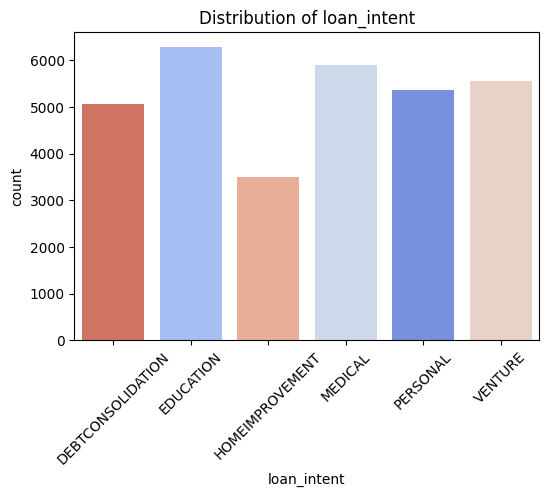

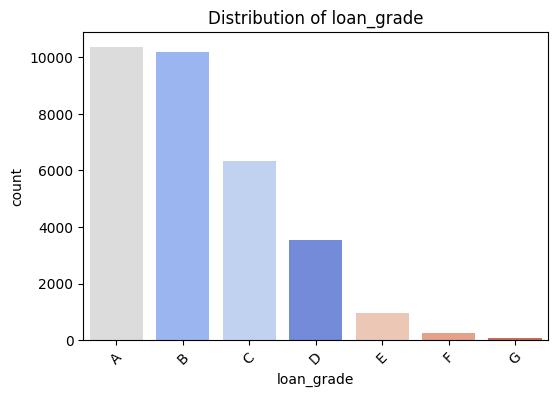

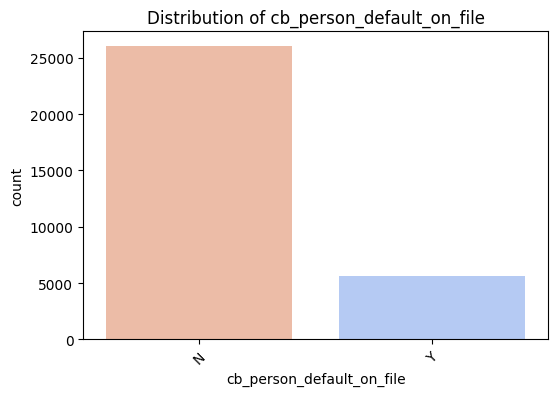

In [ ]:
categorical_features = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

for feature in categorical_features:
    plt.figure(figsize=(6, 4))
    sorted_categories = sorted(df[feature].unique())
    sns.countplot(x=df[feature], order=sorted_categories, hue=df[feature], palette="coolwarm", legend=False)
    plt.title(f"Distribution of {feature}")
    plt.xticks(rotation=45)
    plt.show()
    print("\n")

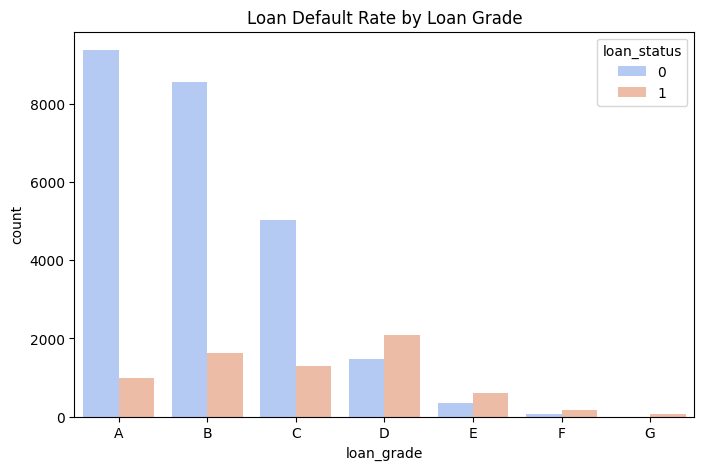

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df['loan_grade'], hue=df['loan_status'], order=sorted(df['loan_grade'].unique()), palette="coolwarm")
plt.title("Loan Default Rate by Loan Grade")
plt.show()

In [ ]:
bins = [0, 15000, 30000, 45000, 60000, 70000]
labels = ["Very Low", "Low", "Medium", "High", "Very High"]

df_copy = df.copy()
df_copy["income_category"] = pd.cut(df_copy["person_income"], bins=bins, labels=labels, include_lowest=True)

grouped_df = df_copy.groupby("income_category")["loan_status"].mean().reset_index()

print(grouped_df)

  income_category  loan_status
0        Very Low     0.835000
1             Low     0.409501
2          Medium     0.278669
3            High     0.195702
4       Very High     0.156126


<ipython-input-50-5c32b0a2fc44>:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = df_copy.groupby("income_category")["loan_status"].mean().reset_index()


In [ ]:
for col in categorical_features:
    df[col] = le.fit_transform(df[col])

print("Encoded Data Sample:")
print(df.head())

Encoded Data Sample:
   person_age  person_income  person_home_ownership  person_emp_length  \
0          22          59000                      3              123.0   
1          21           9600                      2                5.0   
2          25           9600                      0                1.0   
3          23          65500                      3                4.0   
4          24          54400                      3                8.0   

   loan_intent  loan_grade  loan_amnt  loan_int_rate  loan_status  \
0            4           3      35000          16.02            1   
1            1           1       1000          11.14            0   
2            3           2       5500          12.87            1   
3            3           2      35000          15.23            1   
4            3           2      35000          14.27            1   

   loan_percent_income  cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                 

# Benchmark：Naïve Bayes and Logistic Regression

# Logistic Regression for Classification

**Logistic Regression** is a linear model for classification tasks. It uses the *logistic (sigmoid) function* to map a linear combination of input features to a probability between 0 and 1. Formally, for an input feature vector $x$, the predicted probability of belonging to the positive class (label 1) is:

$$
P(y=1 \mid x) = \sigma(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}
$$

where $w$ is the weight vector, $b$ is the bias term, and $\sigma$ denotes the sigmoid function.

During training, Logistic Regression typically minimizes the *cross-entropy loss* (or log loss):

$$
J(w, b)
= -\frac{1}{N} \sum_{i=1}^{N}
\Big[\, y_i \log \big(\hat{y}_i\big) \;+\; (1-y_i) \log\big(1-\hat{y}_i\big) \Big],
$$

where $N$ is the number of samples, $y_i$ is the true label for the $i$-th sample, and $\hat{y}_i = \sigma(w^T x_i + b)$ is the predicted probability for the $i$-th sample. By iteratively updating $w$ and $b$ to minimize $J(w, b)$, Logistic Regression learns a decision boundary that separates the classes as effectively as possible.

To decide the final class label $\hat{y}$, we usually apply a threshold (often 0.5) to this probability:

$$
\hat{y} =
\begin{cases}
1, & \text{if } P(y=1 \mid x) \ge 0.5,\\
0, & \text{otherwise}.
\end{cases}
$$

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from matplotlib.colors import ListedColormap


In [ ]:
# Define the target variable and features
target = "loan_status"
features = [col for col in df.columns if col != target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    df[features], df[target], test_size=0.2, random_state=42
)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=500, solver='lbfgs')
lr_model.fit(X_train, y_train)

# Make predictions
y_pred = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

# **Evaluation**
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"Logistic Regression Accuracy: {accuracy:.4f}, AUC: {auc_score:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# **Plot confusion matrix**
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=["No Default", "Default"], yticklabels=["No Default", "Default"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


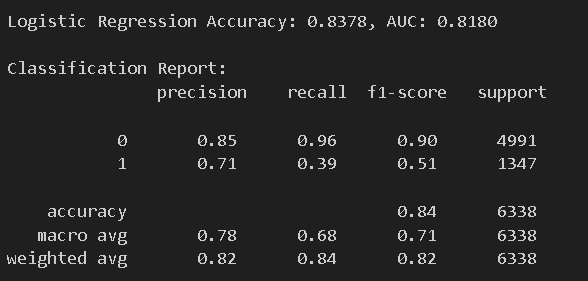

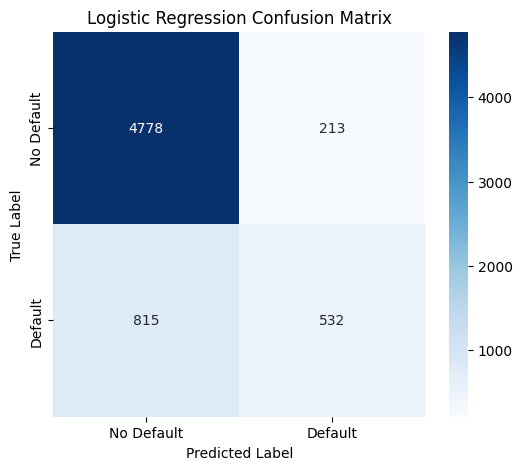

In [ ]:
# **Plot the ROC Curve**
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Reference line for random classification
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC Curve")
plt.legend(loc="lower right")
plt.show()

# **Plot the decision boundary (selecting only two main features for visualization)**
# Select two features
feature_1, feature_2 = "person_income", "cb_person_cred_hist_length"
X_vis = df[[feature_1, feature_2]].values
y_vis = df[target].values

# Train Logistic Regression
lr_vis = LogisticRegression(max_iter=500)
lr_vis.fit(X_vis, y_vis)

# Generate mesh grid data
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = lr_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(("lightblue", "lightcoral")))
scatter = plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap=ListedColormap(("blue", "red")), edgecolor="k", marker="o")
plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.title("Logistic Regression Decision Boundary")
plt.legend(handles=scatter.legend_elements()[0], labels=["No Default", "Default"])
plt.show()


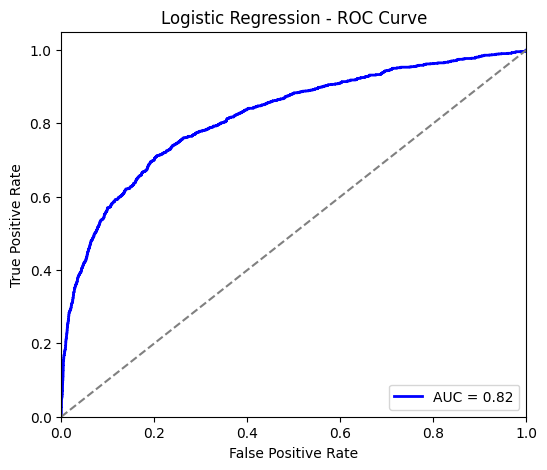

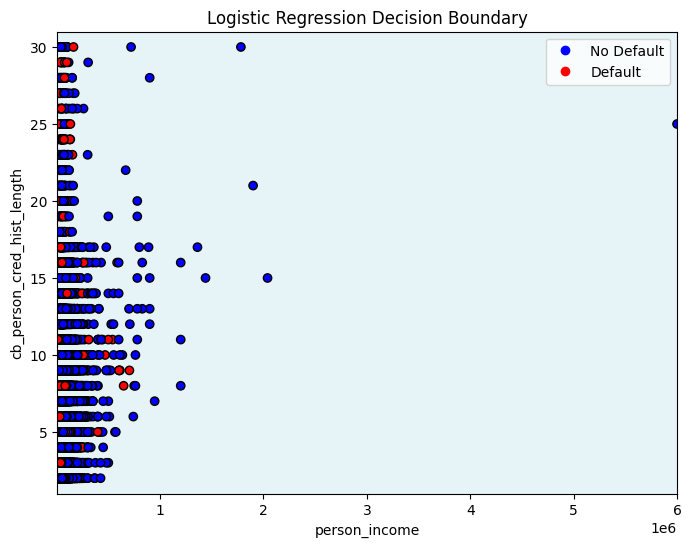

# Naive Bayes for Classification

**Naive Bayes** is a probabilistic classifier that applies Bayes' theorem with a strong (naive) independence assumption among features. For a feature vector $x = (x_1, x_2, \dots, x_n)$ and a class variable $y$, Bayes' theorem can be written as:

$$
P(y \mid x) = \frac{P(x \mid y) P(y)}{P(x)}
$$

Since $P(x)$ is constant for all classes during classification, the class prediction is obtained by finding the class that maximizes the posterior probability:

$$
\hat{y} = \arg\max_{y} \; P(y \mid x) = \arg\max_{y} \; P(x \mid y) P(y)
$$

Under the naive assumption that the features are conditionally independent given the class, the likelihood term can be factorized as:

$$
P(x \mid y) = \prod_{i=1}^{n} P(x_i \mid y)
$$

Thus, the decision rule becomes:

$$
\hat{y} = \arg\max_{y} \; P(y) \prod_{i=1}^{n} P(x_i \mid y)
$$

In practice, to improve numerical stability and simplify computation, the logarithm is applied, resulting in:

$$
\hat{y} = \arg\max_{y} \left( \log P(y) + \sum_{i=1}^{n} \log P(x_i \mid y) \right)
$$

This approach allows the Naive Bayes classifier to efficiently compute the probability of each class and make a classification decision based on the highest posterior probability.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

In [ ]:
# Load data
file_path = "./processed_credit_risk_dataset.csv"
df = pd.read_csv(file_path)

# Target variable and features
target = "loan_status"
features = [col for col in df.columns if col != target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    df[features], df[target], test_size=0.2, random_state=42
)

# Train Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Make predictions
y_pred = nb_model.predict(X_test)
y_pred_proba = nb_model.predict_proba(X_test)[:, 1]

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Display confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=["No Default", "Default"], yticklabels=["No Default", "Default"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Naïve Bayes Confusion Matrix")
plt.show()


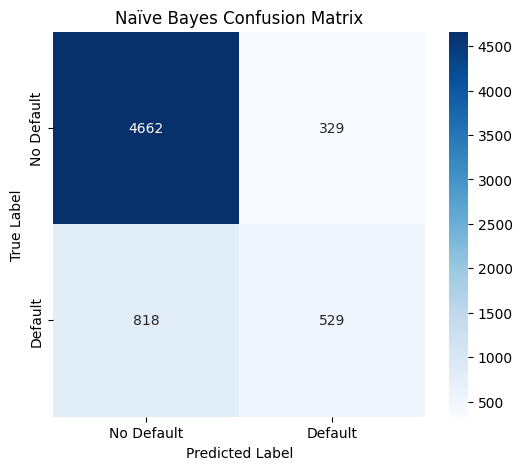

In [ ]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Naïve Bayes Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

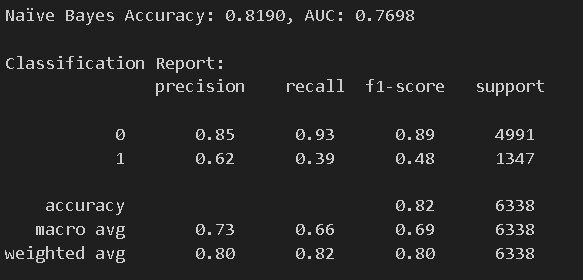

In [ ]:
# Calculate the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Reference line for random classifier
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Naïve Bayes - ROC Curve")
plt.legend(loc="lower right")
plt.show()

# **Plot the decision boundary (using only two main features for visualization)**
from matplotlib.colors import ListedColormap

# Select two features
feature_1, feature_2 = "person_income", "cb_person_cred_hist_length"
X_vis = df[[feature_1, feature_2]].values
y_vis = df[target].values

# Train Naïve Bayes
nb_vis = GaussianNB()
nb_vis.fit(X_vis, y_vis)

# Generate grid data
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = nb_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(("lightblue", "lightcoral")))
scatter = plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap=ListedColormap(("blue", "red")), edgecolor="k", marker="o")
plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.title("Naïve Bayes Decision Boundary")
plt.legend(handles=scatter.legend_elements()[0], labels=["No Default", "Default"])
plt.show()


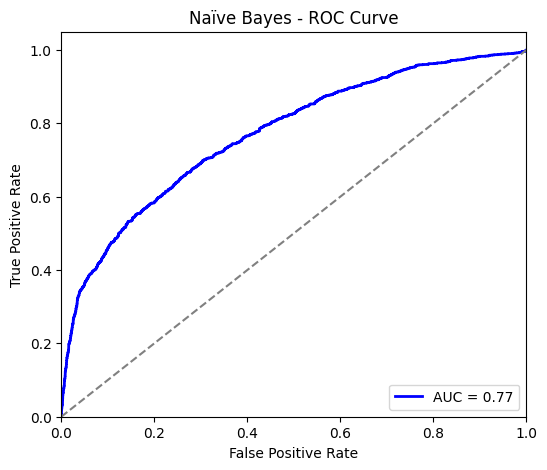

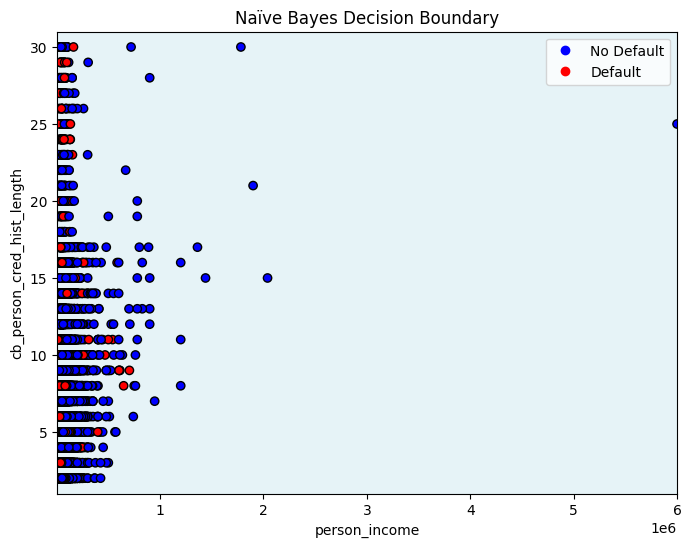

# Bayesian Logistic Regression
## What is BLR?
Bayesian Logistic Regression (BLR) is a probabilistic approach to binary classification that extends traditional logistic regression by incorporating **Bayesian inference**. Unlike standard logistic regression, which estimates model parameters using **maximum likelihood estimation (MLE)**, BLR treats model parameters as **random variables** and assigns them a **prior distribution**. This allows us to obtain **a full posterior distribution** over the model parameters instead of just point estimates.

Mathematically, BLR follows the same logit transformation as logistic regression:

$$ P(Y=1 | X, \beta) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_n X_n)}} $$

where:
- ${Y}$  is the binary outcome (default = 1, non-default = 0).
- ${X_i}$ are the predictor variables such as income, loan amount, and interest rate.
- ${\beta}$ are the model coefficients, which in BLR are **random variables** rather than fixed parameters.

Using **Bayes' Theorem**, the posterior distribution of ${\beta}$ is computed as:

$$P(\beta | X , y) = \frac{P(y| \beta, X)P(\beta|X)}{P(X, y)}$$

where:
- ${P(\beta|X)}$  is the **prior** distribution, encoding our belief about ${\beta}$ before observing data.
- ${P(y| \beta, X)}$ is the **likelihood**, describing how likely the observed data is given the parameters.
- ${P(X, y)}$ is the **evidence**, which normalizes the posterior.
- ${P(\beta | X , y)}$ is the **posterior**, representing the updated belief about ${\beta}$ after observing data.

Since ${P(X, y)}$ is often intractable, we use **Markov Chain Monte Carlo (MCMC) sampling** to approximate the posterior.

## Why BLR for Credit Assessment?

Credit assessment is inherently probabilistic, meaning lenders need to not only predict whether a borrower will default but also understand uncertainty in that prediction. Bayesian Logistic Regression provides several advantages in this context:
###1. Uncertainty Estimation

Unlike standard logistic regression, which provides point estimates for coefficients, BLR gives posterior distributions, allowing us to quantify the uncertainty in our predictions.

###2. Better Interpretability with Credible Intervals

Traditional logistic regression provides fixed coefficients for features, whereas BLR gives credible intervals (HDI 95%), which help determine the range within which the true coefficient is likely to lie.

###3. Business Impact: Risk-Aware Decision Making

BLR helps lenders assess risk with confidence intervals, allowing financial institutions to fine-tune loan approval policies.


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Bayesian/Bayesian Group/processed_credit_risk_dataset.csv')
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,3,123.0,4,3,35000,16.02,1,0.59,1,3
1,21,9600,2,5.0,1,1,1000,11.14,0,0.10,0,2
2,25,9600,0,1.0,3,2,5500,12.87,1,0.57,0,3
3,23,65500,3,4.0,3,2,35000,15.23,1,0.53,0,2
4,24,54400,3,8.0,3,2,35000,14.27,1,0.55,1,4


### Train-Test Split
To evaluate our model's performance, we split the dataset into training and testing sets. We allocate 200 samples for testing and use the rest for training.

### Feature Scaling
Since Bayesian Logistic Regression (BLR) uses MCMC sampling, feature scaling is crucial to ensure better convergence.

In [ ]:
# Extract the features and the labels
X = data.drop(columns='loan_status')
y = data.loan_status

# Split into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 50)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
feature_names = X.columns
y.value_counts(dropna=False)

,count
loan_status,
0,24860
1,6826


## Bayesian Logistic Regression (BLR) Model Training

We implemented a Bayesian Logistic Regression model using **PyMC**, where model parameters ${\beta}$ were treated as **random variables** with **normal priors** ${N(0,10)}$. The likelihood function was modeled as a **Bernoulli distribution** based on the sigmoid transformation of **logits**.

To estimate the posterior distribution, we performed **MCMC** sampling using **NUTS (No-U-Turn Sampler)**. We ran **2000 samples** with target_accept=0.95 to ensure effective exploration of the parameter space. The sampling results show **no divergences**, indicating a stable and well-converged model.



In [ ]:
# PyMC for Bayesian Inference
import pymc as pm

In [ ]:
with pm.Model() as blr_model:
    # 1️.Prior distribution: normal distribution
    beta = {name: pm.Normal(name, mu=0, sigma=10) for name in feature_names}  # 11 features
    intercept = pm.Normal('intercept', mu=0, sigma=10)

    # 2. Define the logits function, computing the linear transformation of the inputs
    logits = intercept + sum(beta[name] * X_train_scaled[:, i] for i, name in enumerate(feature_names))

    # 3️. Apply the sigmoid function, which converts logits into probabilities.
    p = pm.math.sigmoid(logits)

    # 4️. Model the observed data as a Bernoulli distribution
    y_obs = pm.Bernoulli('y_obs', p=p, observed=y_train)

    # 5️.MCMC Sampling
    trace = pm.sample(2000, return_inferencedata=True, target_accept=0.95)


Output()

## Forest Plot
The forest plot visualizes the posterior distributions of the model coefficients by displaying their 94% Highest Density Interval (HDI).
- Identify which variables significantly influence credit default risk.
- Determine the level of uncertainty in each coefficient estimate.
- Compare the relative effect of different variables.

In [ ]:
import arviz as az

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

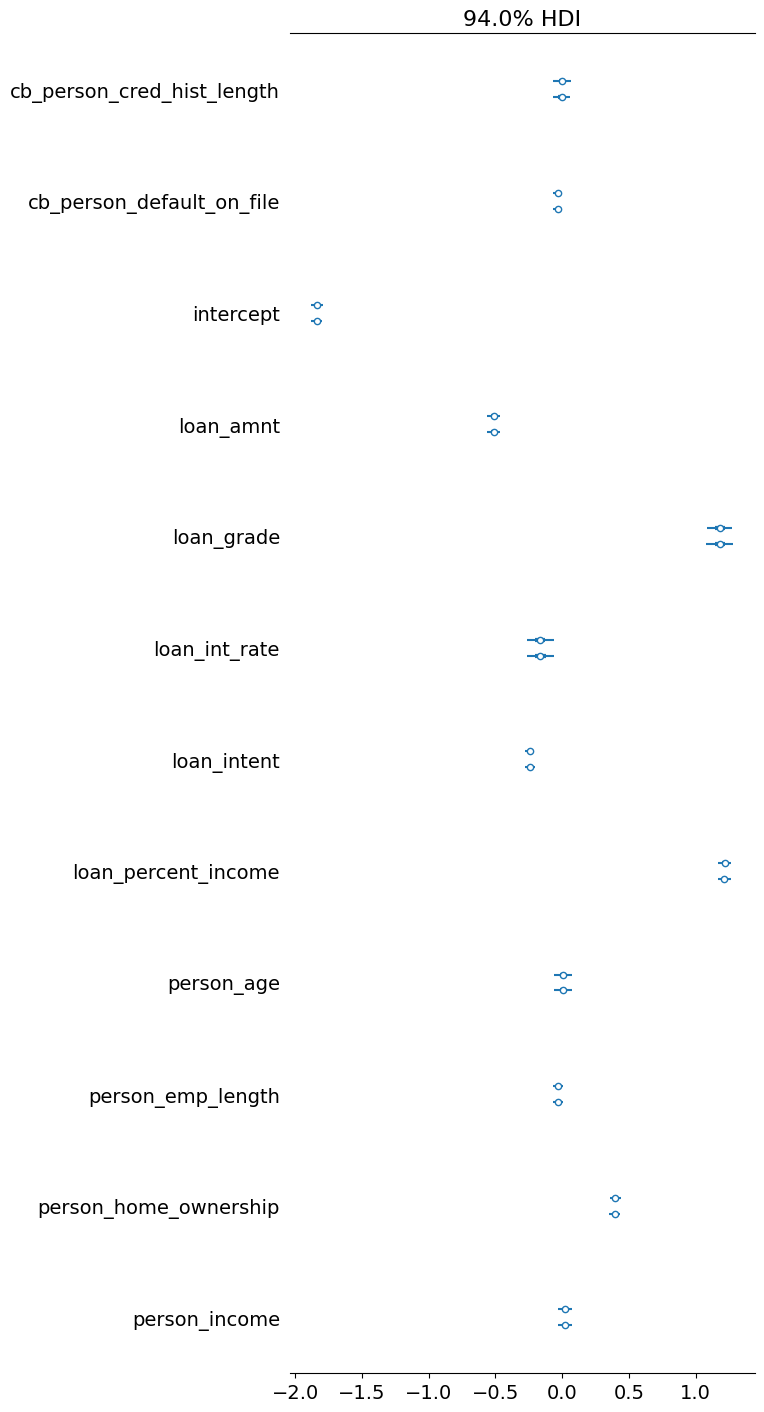

In [ ]:
figsize(8, 8)
az.plot_forest(trace)

### Explanation:
- Y-axis (Vertical Labels): Represents the model features (predictor variables).
- X-axis (Horizontal Scale): Represents the estimated values of the coefficients.
- Dots: Represent the mean (central estimate) of the posterior distribution for each coefficient.
- Horizontal Lines: Represent the 94% Highest Density Interval (HDI), indicating the range within which the true coefficient likely falls with 94% probability.

### Conclusion:
- **Positive Coefficients**: Features whose mean and HDI are closer to the right (positive values) increase the probability of loan default (e.g., loan interest rate and previous default record).
- **Longer HDI Lines**: Indicate greater uncertainty in the effect of a variable, meaning its influence on default risk is less certain (e.g., loan amount and employment length).

## Posterior Distribution Plot


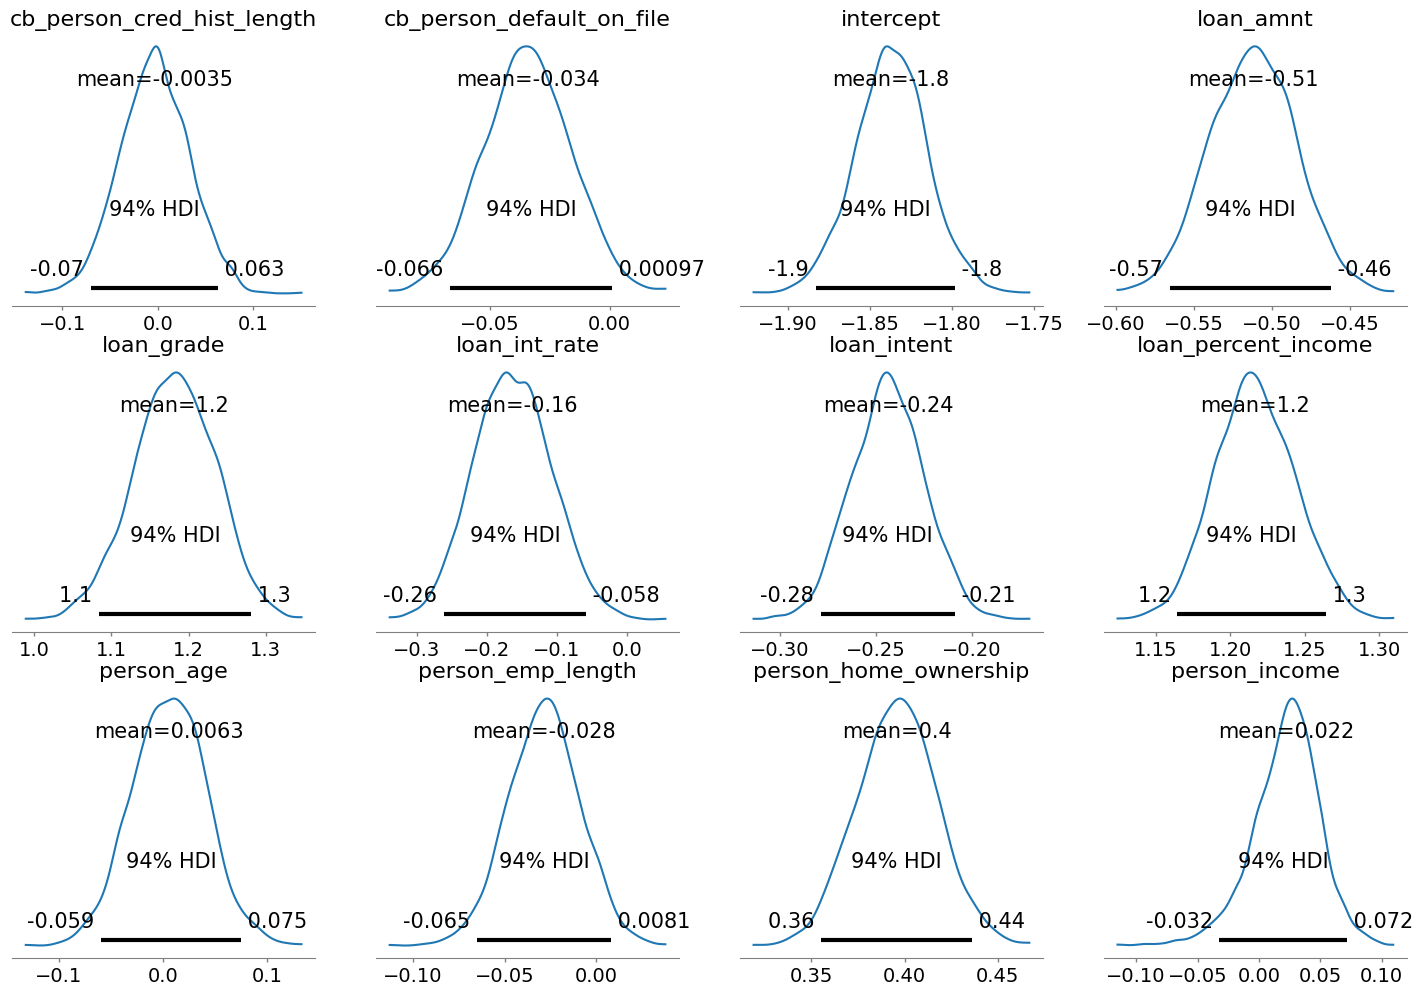

In [ ]:
figsize(10, 12)

az.plot_posterior(trace, figsize=(18, 12), grid=(3, 4))
plt.show()

### Sensitivity Analysis of Multiple Features on Default Probability
The function model_effect_multiple() generates plots to analyze how each feature impacts the probability of default (P(Y=1)).
- Fix the median of all other variables while changing one feature at a time.
- Calculate the probability of default for different values of that feature using the posterior mean from our Bayesian Logistic Regression model.
- Plot the effect of each variable on the probability of default.


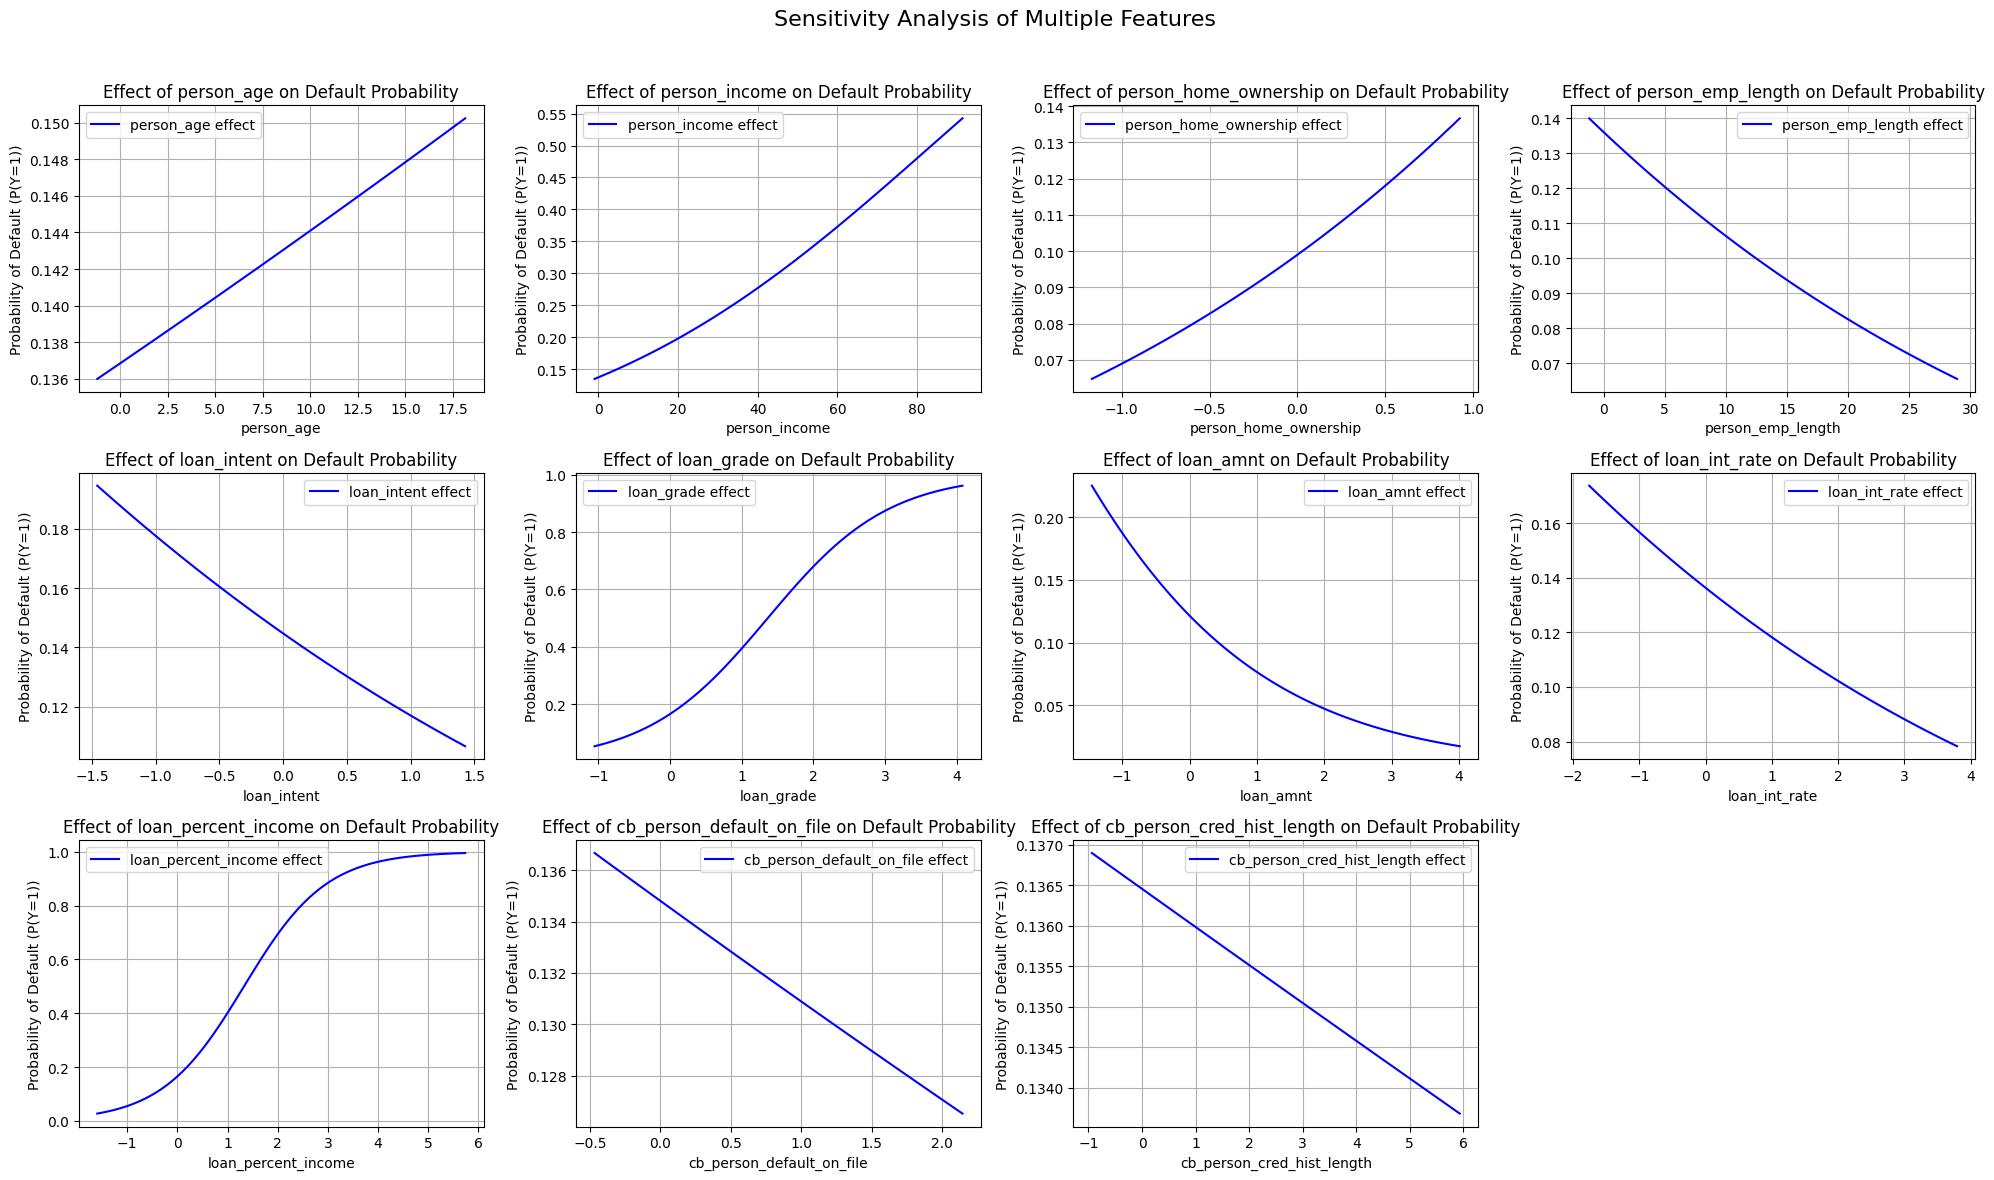

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

def model_effect_multiple(query_vars, trace, X, num_samples=100):

    # Getting the posterior mean
    summary_stats = az.summary(trace)
    betas = summary_stats['mean'].to_dict()

    num_vars = len(query_vars)
    rows, cols = 3, 4
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for i, query_var in enumerate(query_vars):
        # Fix the median of all variables
        steady_vars = list(X.columns)
        steady_vars.remove(query_var)

        # Setting the range of query_var
        var_min, var_max = X[query_var].min(), X[query_var].max()
        x_range = np.linspace(var_min, var_max, num_samples)

        # Constructing a sample of averages
        X_sample = X.median().values.copy()

        # Calculate P(Y=1) for different values of query_var.
        p_values = []
        for x in x_range:
            X_sample[list(X.columns).index(query_var)] = x  # Change only query_var
            logits = betas['intercept'] + sum(betas[name] * X_sample[j] for j, name in enumerate(X.columns))
            p = 1 / (1 + np.exp(-logits))  # Calculating sigmoid probabilities
            p_values.append(p)

        # Plotting the impact curve of the current variable
        axes[i].plot(x_range, p_values, label=f"{query_var} effect", color='blue')
        axes[i].set_xlabel(query_var)
        axes[i].set_ylabel("Probability of Default (P(Y=1))")
        axes[i].set_title(f"Effect of {query_var} on Default Probability")
        axes[i].legend()
        axes[i].grid()


    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Sensitivity Analysis of Multiple Features", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
model_effect_multiple(feature_names, trace, X_train_scaled)


              precision    recall  f1-score   support

           0       0.87      0.96      0.91      4993
           1       0.74      0.47      0.57      1345

    accuracy                           0.85      6338
   macro avg       0.80      0.71      0.74      6338
weighted avg       0.84      0.85      0.84      6338



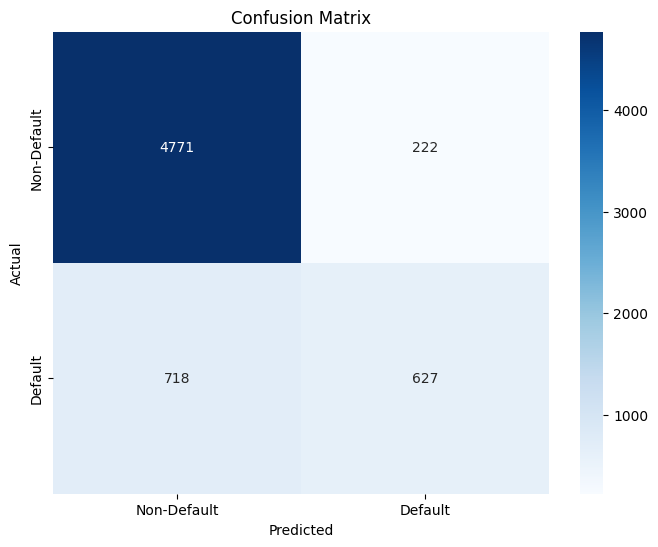

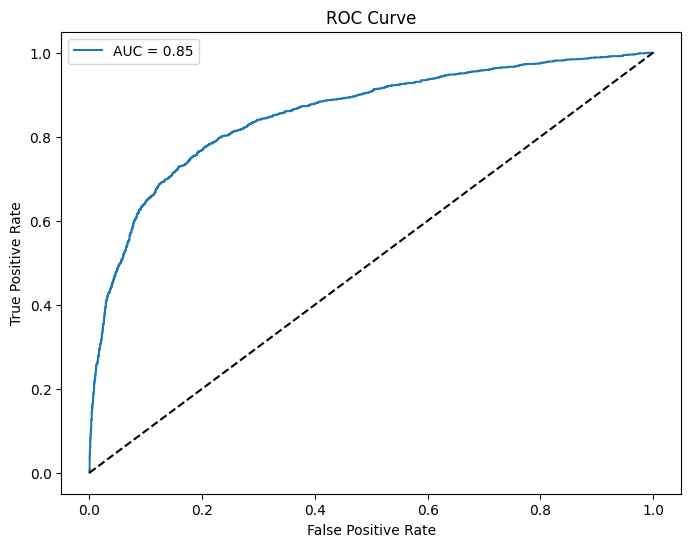

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             f1_score, roc_auc_score, recall_score,
                             precision_score, roc_curve)

def evaluate_bayesian_model(trace, X_test, y_test, feature_names):
    # Get the a posteriori parameter mean
    summary_stats = az.summary(trace)
    betas_mean = summary_stats['mean']

    # Extract coefficients
    intercept = betas_mean['intercept']
    coefs = np.array([betas_mean[col] for col in feature_names])

    # Calculate predictive probabilities
    logits = intercept + X_test.dot(coefs)
    y_prob = 1 / (1 + np.exp(-logits))
    y_pred = (y_prob >= 0.5).astype(int)

    print(classification_report(y_test, y_pred))

    # Calculate indicators
    conf_matrix = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    # print(f"Accuracy: {accuracy:.4f}")
    # print(f"Precision: {precision:.4f}")
    # print(f"Recall: {recall:.4f}")
    # print(f"F1 Score: {f1:.4f}")
    # print(f"ROC AUC: {roc_auc:.4f}")

    # Confusion metrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Default', 'Default'],
                yticklabels=['Non-Default', 'Default'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

    return {
        'confusion_matrix': conf_matrix,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }


metrics = evaluate_bayesian_model(trace, X_test_scaled, y_test, feature_names)

# Bayesian Augmented Decision Trees (BADT)

## BADT Model
Bayesian Augmented Decision Trees (**BADT**) is a **Bayesian ensemble learning method** that models the relationship between input features and the target variable using **decision trees** in a fully **Bayesian framework**. BADT provides **predictive uncertainty estimation**, making it particularly useful in **high-dimensional and complex non-linear tasks**.

BADT extends traditional decision tree models by incorporating **Bayesian priors** and **posterior inference**, allowing the model to estimate **not only predictions but also their uncertainty**.

---

BADT models the **target variable** \( Y \) as a sum of multiple weak **decision trees**:  

$$
f(X) = \sum_{t=1}^{m} g_t(X) + \epsilon
$$

where:  
- \( g_t(X) \) represents the **\( t \)-th decision tree** in the ensemble.  
- \( m \) is the **total number of trees**.  
- \( \epsilon \) is the **error term**, often modeled as Gaussian noise.  

Unlike traditional decision trees, BADT **does not perform greedy splitting**; instead, it **samples trees from a Bayesian posterior distribution** using **Markov Chain Monte Carlo (MCMC)** methods.

---

## Key Features of BADT
✔ **Fully Bayesian Framework** – Provides **posterior probability distributions** instead of point estimates.  
✔ **Ensemble of Decision Trees** – Combines multiple weak trees to improve generalization.  
✔ **Handles Non-Linearity** – Works well with complex, **non-linear relationships** between features and the target variable.  
✔ **Uncertainty Estimation** – Unlike traditional decision trees, BADT quantifies the **confidence** of predictions.  
✔ **Regularization via Priors** – Bayesian priors help prevent **overfitting**, ensuring smooth and stable predictions.  

# Bayesian Augmented Decision Trees (BADT) for Credit Assessment

Credit assessment is a critical task in banking and finance, where lenders evaluate an applicant's **creditworthiness** before approving loans. Traditional machine learning models like **Logistic Regression, Decision Trees, and XGBoost** are commonly used, but they often fail to quantify **uncertainty** in predictions.

Bayesian Augmented Decision Trees (**BADT**) offer a **probabilistic, non-parametric approach** that is particularly **well-suited for credit risk modeling** by incorporating **uncertainty estimation and adaptive learning**.

---

## Key Advantages of BADT for Credit Risk Assessment
BADT provides several benefits compared to traditional credit risk models:

### Uncertainty Estimation  
✔ Unlike traditional decision trees or neural networks, **BADT provides a full posterior distribution** rather than just a single point estimate.  
✔ Helps financial institutions **quantify risk more accurately** by understanding **prediction confidence**.  

🔹 **Example**: If a borrower has a predicted **loan default probability of 0.45**, BADT can also estimate the **range of possible probabilities**, say **(0.30 – 0.60)**, providing valuable insight into the uncertainty of the prediction.

---

### Non-Linear and Adaptive Modeling  
✔ Credit risk factors such as **income, employment history, and debt-to-income ratio** often interact **non-linearly**.  
✔ BADT **automatically captures complex relationships** without requiring manual feature engineering.

🔹 **Example**: Instead of assuming a **linear relationship between income and loan default**, BADT **learns from the data** and adjusts its decision trees dynamically.

---

### Robustness to Overfitting  
✔ Traditional decision trees and random forests **tend to overfit small datasets**, but BADT **incorporates Bayesian regularization** through priors.  
✔ This makes BADT **highly resistant to overfitting**, even with limited data.

🔹 **Example**: If a dataset has **few loan defaults**, BADT prevents **overconfidence in predictions** by incorporating **prior knowledge**.

---

In [ ]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv("credit_risk_dataset.csv")

# === Data Cleaning and Enhancement ===
# Handling outliers in age and years of employment
df = df[(df['person_age'] <= 100) & 
        (df['person_age'] >= 18)]  # Legal borrowing age
df = df[df['person_emp_length'] <= 60]

# Handling outliers in income ratio (adding business logic)
df = df[(df['loan_percent_income'] > 0.01) &  # Minimum loan-to-income ratio 1%
        (df['loan_percent_income'] <= 0.85)]   # Maximum loan-to-income ratio 85%
df["loan_int_rate"].fillna(df["loan_int_rate"].median(), inplace=True)

# === Fixing Core Issue: Handling Categorical Variables ===
# Processing binary categorical variables (N/Y conversion)
binary_encoder = LabelEncoder()
df['cb_person_default_on_file'] = binary_encoder.fit_transform(
    df['cb_person_default_on_file'].replace({'N':0, 'Y':1})  # Explicit replacement to ensure no anomalies
)

In [ ]:
# === Dataset Separation Strategy Optimization ===
# Create two copies of the dataset
df_bayes = df.copy()  # Retain original categorical variables for Bayesian network
df_bart = df.copy()   # Used for the BART model

# BART data encoding (enhancing stability)
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade']
df_bart = pd.get_dummies(df_bart, columns=cat_cols, 
                        drop_first=True,
                        dummy_na=True)  # Handle potential missing values

# Ensure all numerical columns are converted to float
num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length']
df_bart[num_cols] = df_bart[num_cols].astype(float)

# Dataset splitting
X_bayes = df_bayes.drop('loan_status', axis=1)
y_bayes = df_bayes['loan_status'].astype(int)

# BART dataset splitting
X_bart = df_bart.drop('loan_status', axis=1).astype(float)  # Enforce type conversion
y_bart = df_bart['loan_status'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X_bart, y_bart, test_size=0.2, stratify=y_bart, random_state=42
)

from imblearn.over_sampling import ADASYN

adasyn = ADASYN(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train, y_train)

# === Added Missing Value Check ===
print("Missing value check:\n", df_bart.isnull().sum())

Missing value check:
 person_age                     0
person_income                  0
person_emp_length              0
loan_amnt                      0
loan_int_rate                  0
loan_status                    0
loan_percent_income            0
cb_person_default_on_file      0
cb_person_cred_hist_length     0
person_home_ownership_OTHER    0
person_home_ownership_OWN      0
person_home_ownership_RENT     0
person_home_ownership_nan      0
loan_intent_EDUCATION          0
loan_intent_HOMEIMPROVEMENT    0
loan_intent_MEDICAL            0
loan_intent_PERSONAL           0
loan_intent_VENTURE            0
loan_intent_nan                0
loan_grade_B                   0
loan_grade_C                   0
loan_grade_D                   0
loan_grade_E                   0
loan_grade_F                   0
loan_grade_G                   0
loan_grade_nan                 0
dtype: int64


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(y_train.shape)  # expected output: (n,)
print(X_train_scaled.shape)  # expected output (25228, n_features)

(25228,)
(25228, 25)


In [ ]:
import pymc3 as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

with pm.Model() as model:
    # BART is used for probabilistic modeling of the relationship and target variable Y using Bernoulli distribution
    w = pm.BART("w", X=X_train_scaled, Y=y_train, m=100)

    # apply a sigmoid function to transform the output into a probability (0 to 1)
    # binary classification problem
    y_pred = pm.Bernoulli("y_pred", p=pm.math.sigmoid(w), observed=y_train)

    # Perform MCMC sampling to estimate the posterior distribution of the model parameters
    trace = pm.sample(3000, tune=1000, chains=1, cores=1, return_inferencedata=True, random_seed=42)

# === Perform posterior predictive sampling ===
with model:
    posterior_samples = pm.sample_posterior_predictive(trace, var_names=["y_pred"])

d:\Programs\Anaconda\envs\bayes2\lib\site-packages\pymc3\distributions\bart.py:251: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def mean(a):
The BART model is experimental. Use with caution.
Sequential sampling (1 chains in 1 job)
PGBART: [w]


Sampling 1 chain for 1_000 tune and 3_000 draw iterations (1_000 + 3_000 draws total) took 7201 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


In [ ]:
# get `y_pred` probability
p_samples = posterior_samples["y_pred"]
p_pred = p_samples.mean(axis=0)[:len(y_test)]

# threshold after testing
threshold = 0.48
y_pred_final = (p_pred > threshold).astype(int)

# === Calculate Measures ===
accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final, zero_division=1)
recall = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)
roc_auc = roc_auc_score(y_test, p_pred)

In [ ]:
# === Results ===
print(f"\n📊 BADT:")
print(f"✅ Accuracy: {accuracy:.4f}")
print(f"✅ Precision(loan_status=1): {precision:.4f}")
print(f"✅ Recall(loan_status=1): {recall:.4f}")
print(f"✅ F1 Score: {f1:.4f}")
print(f"✅ ROC AUC: {roc_auc:.4f}")


📊 BADT:
✅ Accuracy: 0.7357
✅ Precision(loan_status=1): 0.6742
✅ Recall(loan_status=1): 0.9381
✅ F1 Score: 0.7846
✅ ROC AUC: 0.8016


# Summary + Future work


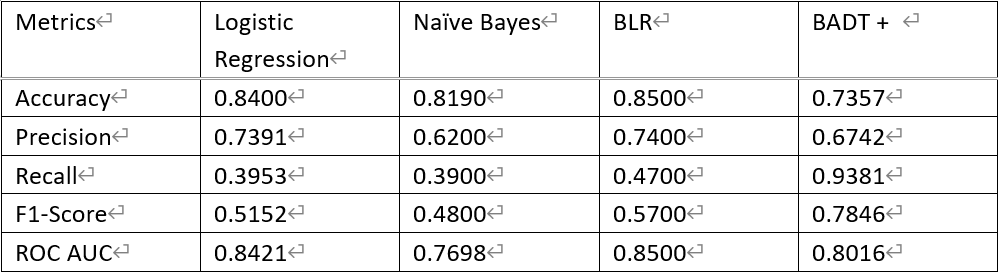



### Summary
This study compared different machine learning and Bayesian models for credit risk assessment. The results highlight key trade-offs between accuracy, precision, recall, and interpretability.

- **Bayesian Logistic Regression (BLR) is the best model**, achieving the highest **accuracy (85%)** and **ROC AUC (0.85)**, making it the most reliable for predicting defaults while maintaining a balance between precision and recall.

- BADT (Bayesian Augmented Decision Tree) demonstrated exceptional **recall (93.81%)** and the highest **F1-score (0.7846)**, meaning it successfully identified most defaulters, making it valuable for risk-sensitive lending.

- Logistic Regression and Naïve Bayes performed well but were outperformed by BLR and BADT in adaptability and predictive power.

### Business Insights

- Risk-Averse Lending: BADT is best for lenders who prioritize identifying high-risk borrowers at the cost of potential false positives.

- Balanced Decision-Making: BLR provides the best trade-off between minimizing loan defaults and maximizing approved loans.

### Future Work

- Hybrid Modeling: Develop an ensemble model combining BLR’s accuracy with BADT’s recall to create a risk-adjusted lending strategy.

- Dynamic Bayesian Networks: Enhance BADT+ with time-series Bayesian updating, allowing real-time risk assessment as borrower behavior evolves.